# Tichy's Einblick
Load Tichy's Einblick CSV files and create a DataFrame named `df`.

In [1]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Tichy's Einblick"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
df.head()


Loaded 3126 rows from 195 file(s) in /Users/gretawette/Documents/Thesis/data/raw/Alternative Medien/Tichy's Einblick


,title,date,url,author,teaser,article_text,source,source_file
0,Wegen Geschäften mit Russland: Trump droht Ind...,2025-08-01,https://www.tichyseinblick.de/kolumnen/aus-all...,Seyed Alireza Mousavi,Die von US-Präsident Trump in den vergangenen ...,Im Bemühen um ein Friedensabkommen mit der Ukr...,Tichy's Einblick,articles_2025-08-01.csv
1,Wie robust ist der verfassungsrechtliche Schut...,2025-08-01,https://www.tichyseinblick.de/feuilleton/buech...,Roland Tichy,"""Bargeld liebt dich nicht"", so wirbt ein Zahlu...","Nein, das Bargeld wird nicht abgeschafft. Dies...",Tichy's Einblick,articles_2025-08-01.csv
2,Bis zur Selbstaufgabe: Wie Merz die SPD-Linken...,2025-08-01,https://www.tichyseinblick.de/meinungen/israel...,Mario Thurnes,Aus den Reihen der SPD mehren sich prominente ...,Die Rolle von Malu Dreyer in der SPD wurde 201...,Tichy's Einblick,articles_2025-08-01.csv
3,Bayern führt Wassercent ein,2025-08-01,https://www.tichyseinblick.de/meinungen/bayern...,Thomas Kolbe,Bayerns Ministerpräsident Markus Söder zieht d...,Ab dem 1. Juli 2026 bittet der Freistaat Bayer...,Tichy's Einblick,articles_2025-08-01.csv
4,Klima-Terroristen: Linke sind nicht nett,2025-08-01,https://www.tichyseinblick.de/meinungen/linke-...,Anna Diouf,Linksextremismus als geringeres Übel – und irg...,In NRW ist nach dem Anschlag auf einen Kabeltu...,Tichy's Einblick,articles_2025-08-01.csv


In [ ]:
df['date'].min()


## BERTopic

In [2]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


In [3]:
from BERTopic.bertopic_config import BERTopicConfig, title_config
from BERTopic.bertopic_pipeline import run_bertopic_pipeline


In [4]:
# Prepare Tichy's Einblick dataframe for topic modeling
df_clean = df[["title", "date", "url", "article_text"]].copy()
df_clean["day"] = pd.to_datetime(df_clean["date"], errors="coerce")

df_clean["article_text"] = (
    df_clean["article_text"]
    .astype("string")
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

df_clean["title"] = (
    df_clean["title"]
    .astype("string")
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

df_clean = df_clean.dropna(subset=["day", "url"]).copy()

df_clean = df_clean[
    (df_clean["day"] >= "2025-08-01") & (df_clean["day"] <= "2026-01-31")
].copy()

print(f"Rows prepared for BERTopic: {len(df_clean):,}")
df_clean[["title", "article_text", "day", "url"]].head()


Rows prepared for BERTopic: 2,946


,title,day,url,article_text
0,Wegen Geschäften mit Russland: Trump droht Ind...,2025-08-01,https://www.tichyseinblick.de/kolumnen/aus-all...,Im Bemühen um ein Friedensabkommen mit der Ukr...
1,Wie robust ist der verfassungsrechtliche Schut...,2025-08-01,https://www.tichyseinblick.de/feuilleton/buech...,"Nein, das Bargeld wird nicht abgeschafft. Dies..."
2,Bis zur Selbstaufgabe: Wie Merz die SPD-Linken...,2025-08-01,https://www.tichyseinblick.de/meinungen/israel...,Die Rolle von Malu Dreyer in der SPD wurde 201...
3,Bayern führt Wassercent ein,2025-08-01,https://www.tichyseinblick.de/meinungen/bayern...,Ab dem 1. Juli 2026 bittet der Freistaat Bayer...
4,Klima-Terroristen: Linke sind nicht nett,2025-08-01,https://www.tichyseinblick.de/meinungen/linke-...,In NRW ist nach dem Anschlag auf einen Kabeltu...


In [5]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="article_text",
    config=BERTopicConfig(),
    id_col="url",
    source_name="Tichys_Einblick",
)

# 2) BERTopic on titles only
result_title = run_bertopic_pipeline(
    df=df_clean,
    text_col="title",
    config=title_config(),
    id_col="url",
    source_name="Tichys_Einblick",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-06 15:51:28,820 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/92 [00:00<?, ?it/s]

2026-03-06 15:51:57,039 - BERTopic - Embedding - Completed ✓
2026-03-06 15:51:57,040 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-06 15:52:09,300 - BERTopic - Dimensionality - Completed ✓
2026-03-06 15:52:09,302 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-06 15:52:09,378 - BERTopic - Cluster - Completed ✓
2026-03-06 15:52:09,388 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-06 15:52:11,575 - BERTopic - Representation - Completed ✓


In [12]:
topic_info = result["topic_info"]

topic_info_view = topic_info.drop(columns=["Representative_Docs"], errors="ignore")

with pd.option_context(
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None
):
    display(topic_info_view.head(20))


,Topic,Count,Name,Representation
0,-1,1130,-1_klingbeil_wolfram_drohnen_wolfram weimer,"[klingbeil, wolfram, drohnen, wolfram weimer, media, kirk, günther, group, söder, lanz]"
1,0,297,0_klingbeil_dollar_rente_hersteller,"[klingbeil, dollar, rente, hersteller, aktien, porsche, bürokratie, rentner, gold, höhere]"
2,1,161,1_bsw_wagenknecht_cdu csu_rheinland,"[bsw, wagenknecht, cdu csu, rheinland, sachsen, pfalz, rheinland pfalz, bundestagswahl, gersdorf, ludwigshafen]"
3,2,152,2_co2_energiewende_erneuerbaren_wind,"[co2, energiewende, erneuerbaren, wind, gas, klimapolitik, co₂, 2030, emissionen, energien]"
4,3,145,3_trumps_putin_grönland_venezuela,"[trumps, putin, grönland, venezuela, us präsident, selenskyj, moskau, nato, kuba, vance]"
5,4,131,4_ursula_ursula leyen_eu kommission_plattformen,"[ursula, ursula leyen, eu kommission, plattformen, act, musk, digital, brüsseler, dsa, überwachung]"
6,5,119,5_kirche_gott_papst_leo,"[kirche, gott, papst, leo, kirk, böhmermann, weihnachten, christen, christlichen, gottes]"
7,6,116,6_syrer_flüchtlinge_asylbewerber_migrationshintergrund,"[syrer, flüchtlinge, asylbewerber, migrationshintergrund, ndr, schülern, pass, jugendliche, film, straftaten]"
8,7,112,7_amazon spotify_itunes amazon_abonnieren itunes_itunes,"[amazon spotify, itunes amazon, abonnieren itunes, itunes, angezeigt abonnieren, spotify, abonnieren, soundcloud angezeigt, inhalte soundcloud, soundcloud]"
9,8,108,8_lanz_günther_dgb_örr,"[lanz, günther, dgb, örr, daniel günther, markus lanz, richter, wolfram, rundfunk, wolfram weimer]"


In [7]:
doc_info = result["doc_info"]
doc_info.head()


,original_index,document_id,source_name,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,0,https://www.tichyseinblick.de/kolumnen/aus-all...,Tichys_Einblick,Im Bemühen um ein Friedensabkommen mit der Ukr...,3,3_trumps_putin_grönland_venezuela,"[trumps, putin, grönland, venezuela, us präsid...",[Die Berliner taz unkte angesichts „Grönland-P...,trumps - putin - grönland - venezuela - us prä...,0.562729,False
1,1,https://www.tichyseinblick.de/feuilleton/buech...,Tichys_Einblick,"Nein, das Bargeld wird nicht abgeschafft. Dies...",-1,-1_klingbeil_wolfram_drohnen_wolfram weimer,"[klingbeil, wolfram, drohnen, wolfram weimer, ...",[Nach der initialen Recherche von Alexander Wa...,klingbeil - wolfram - drohnen - wolfram weimer...,0.000000,False
2,2,https://www.tichyseinblick.de/meinungen/israel...,Tichys_Einblick,Die Rolle von Malu Dreyer in der SPD wurde 201...,1,1_bsw_wagenknecht_cdu csu_rheinland,"[bsw, wagenknecht, cdu csu, rheinland, sachsen...",[Weil bundesdeutsche Wirklichkeit inzwischen j...,bsw - wagenknecht - cdu csu - rheinland - sach...,1.000000,False
3,3,https://www.tichyseinblick.de/meinungen/bayern...,Tichys_Einblick,Ab dem 1. Juli 2026 bittet der Freistaat Bayer...,0,0_klingbeil_dollar_rente_hersteller,"[klingbeil, dollar, rente, hersteller, aktien,...",[In einem Gespräch mit Bloomberg adressiert de...,klingbeil - dollar - rente - hersteller - akti...,0.643937,False
4,4,https://www.tichyseinblick.de/meinungen/linke-...,Tichys_Einblick,In NRW ist nach dem Anschlag auf einen Kabeltu...,13,13_wegner_brücke_bekennerschreiben_berlins,"[wegner, brücke, bekennerschreiben, berlins, r...",[Die Bahn fährt neue Rekorde ein – und zwar Mi...,wegner - brücke - bekennerschreiben - berlins ...,1.000000,False


In [8]:
tichys_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

tichys_topics.head()


,index,title,date,url,article_text,day,original_index,Topic,Name,Probability
0,0,Wegen Geschäften mit Russland: Trump droht Ind...,2025-08-01,https://www.tichyseinblick.de/kolumnen/aus-all...,Im Bemühen um ein Friedensabkommen mit der Ukr...,2025-08-01,0.0,3.0,3_trumps_putin_grönland_venezuela,0.562729
1,1,Wie robust ist der verfassungsrechtliche Schut...,2025-08-01,https://www.tichyseinblick.de/feuilleton/buech...,"Nein, das Bargeld wird nicht abgeschafft. Dies...",2025-08-01,1.0,-1.0,-1_klingbeil_wolfram_drohnen_wolfram weimer,0.000000
2,2,Bis zur Selbstaufgabe: Wie Merz die SPD-Linken...,2025-08-01,https://www.tichyseinblick.de/meinungen/israel...,Die Rolle von Malu Dreyer in der SPD wurde 201...,2025-08-01,2.0,1.0,1_bsw_wagenknecht_cdu csu_rheinland,1.000000
3,3,Bayern führt Wassercent ein,2025-08-01,https://www.tichyseinblick.de/meinungen/bayern...,Ab dem 1. Juli 2026 bittet der Freistaat Bayer...,2025-08-01,3.0,0.0,0_klingbeil_dollar_rente_hersteller,0.643937
4,4,Klima-Terroristen: Linke sind nicht nett,2025-08-01,https://www.tichyseinblick.de/meinungen/linke-...,In NRW ist nach dem Anschlag auf einen Kabeltu...,2025-08-01,4.0,13.0,13_wegner_brücke_bekennerschreiben_berlins,1.000000


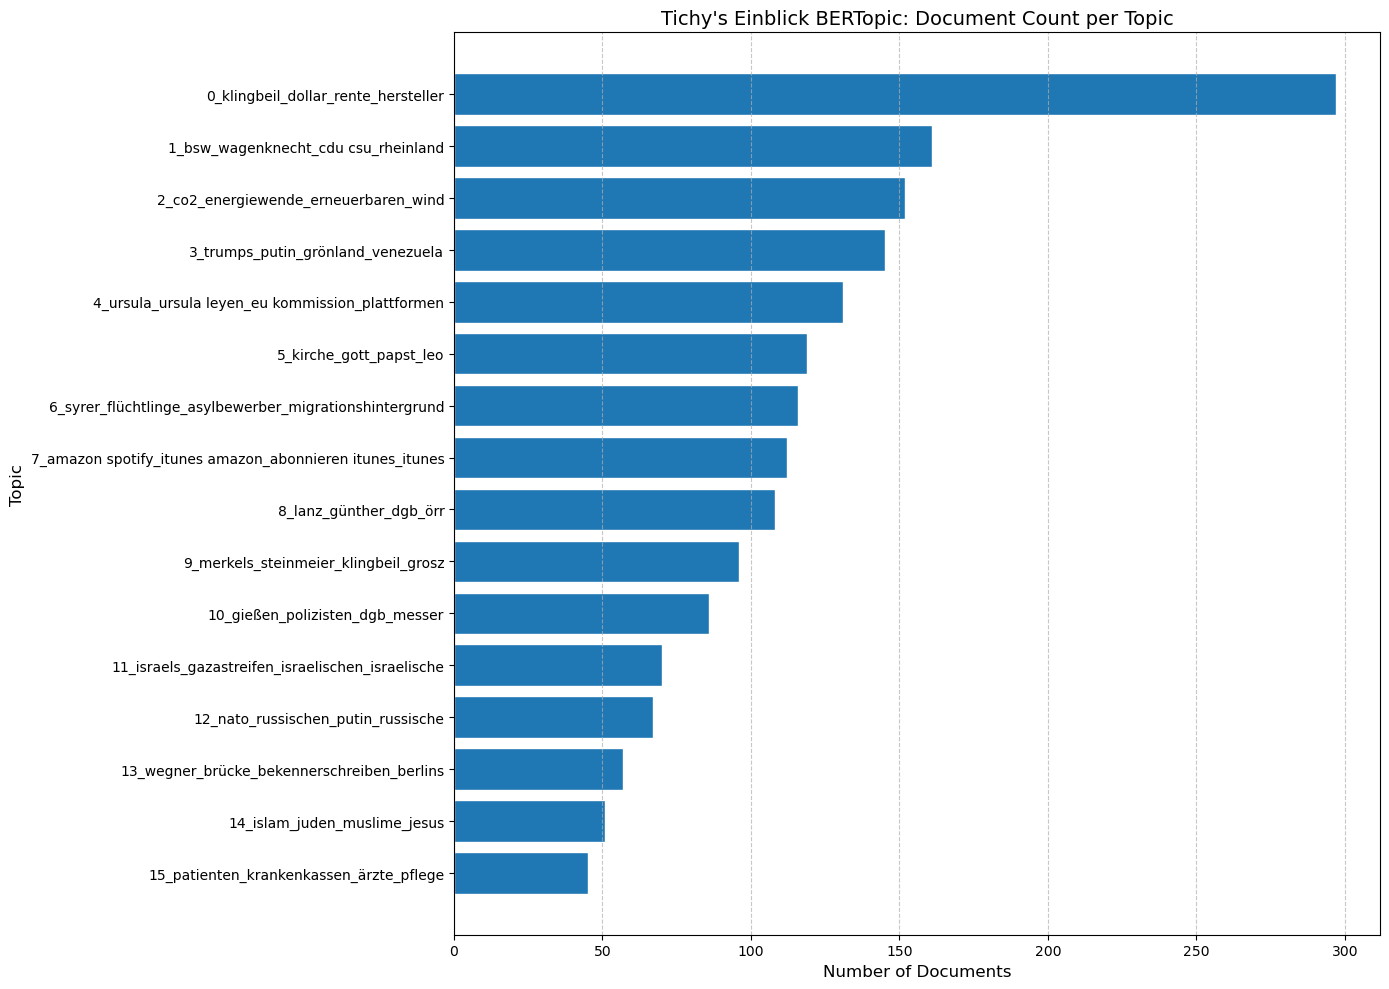

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 10))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info["Topic"] != -1].copy()
topic_counts = topic_counts.nlargest(20, "Count").sort_values("Count", ascending=True)

ax.barh(topic_counts["Name"], topic_counts["Count"], color="#1f77b4", edgecolor="white")

ax.set_xlabel("Number of Documents", fontsize=12)
ax.set_ylabel("Topic", fontsize=12)
ax.set_title("Tichy's Einblick BERTopic: Document Count per Topic", fontsize=14)
ax.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


6it [00:02,  2.95it/s]


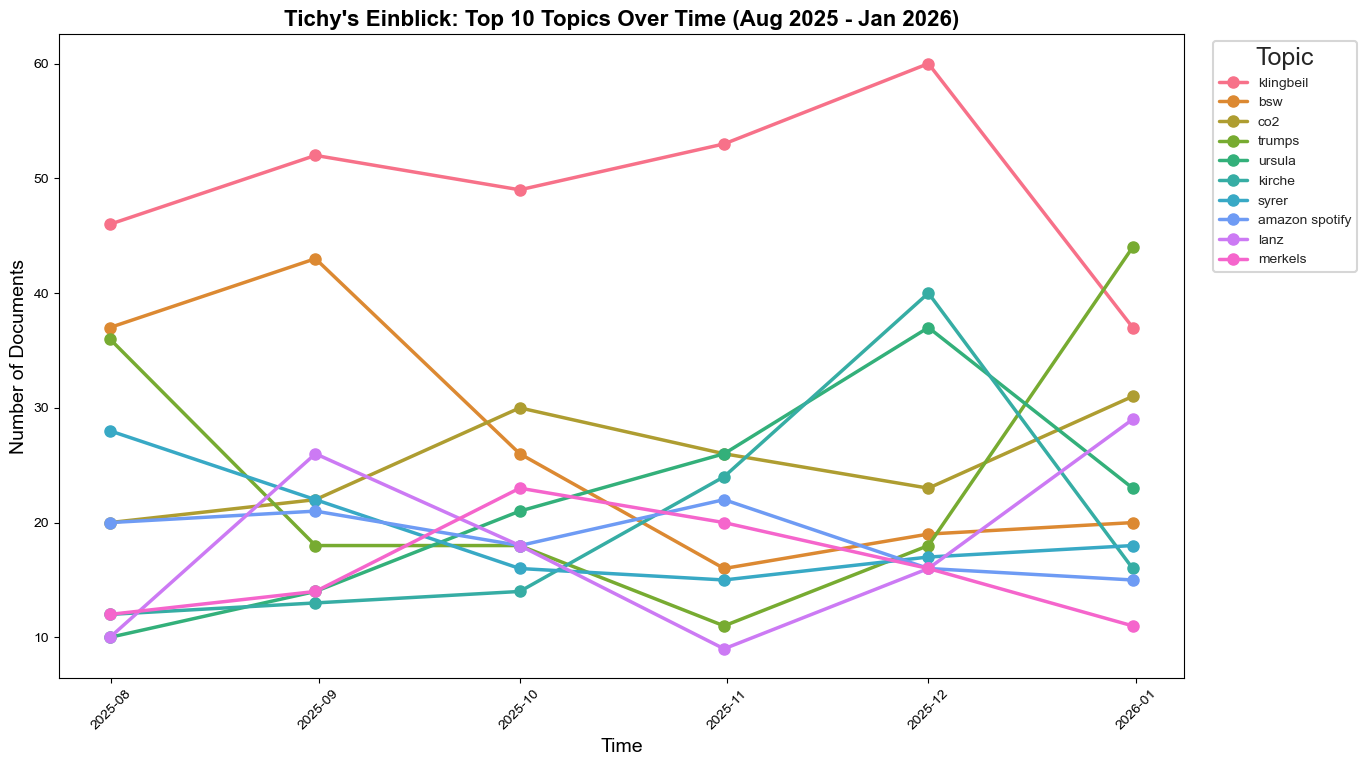

In [10]:
# Prepare data for topics over time
prepared_dates = pd.to_datetime(result["prepared_documents"]["day"], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()
docs_for_time = [doc for doc, ok in zip(result["docs"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    nr_bins=6,
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info["Topic"] != -1].nlargest(10, "Count")["Topic"].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time["Topic"].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info["Topic"], topic_info["Name"]))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered["Topic"] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split("_")[1] if "_" in label else label
    ax.plot(
        topic_data["Timestamp"],
        topic_data["Frequency"],
        marker="o",
        linewidth=2.5,
        markersize=8,
        color=palette[i],
        label=short_label,
    )

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Number of Documents", fontsize=14)
ax.set_title("Tichy's Einblick: Top 10 Topics Over Time (Aug 2025 - Jan 2026)", fontsize=16, fontweight="bold")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# BERTopic v2 run: full text first, then title-only
from BERTopic.bertopic_pipelinev2 import (
    BERTopicV2Config,
    BERTopicV2ConfigTitle,
    run_bertopic_pipeline,
)

result_full_text_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="article_text",
    config=BERTopicV2Config(),
    id_col="url",
    source_name="Tichys_Einblick",
)

result_title_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="title",
    config=BERTopicV2ConfigTitle(),
    id_col="url",
    source_name="Tichys_Einblick",
)

print(
    f"v2 full-text docs: {len(result_full_text_v2['docs']):,} | "
    f"v2 title docs: {len(result_title_v2['docs']):,}"
)

